<a href="https://colab.research.google.com/github/tuanhoangcg2007-pixel/BT2/blob/main/BTVENHA2hc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Giá chuyến đi: 75.00000000000003
Điểm thưởng cho tài xế: 74.20416124837452


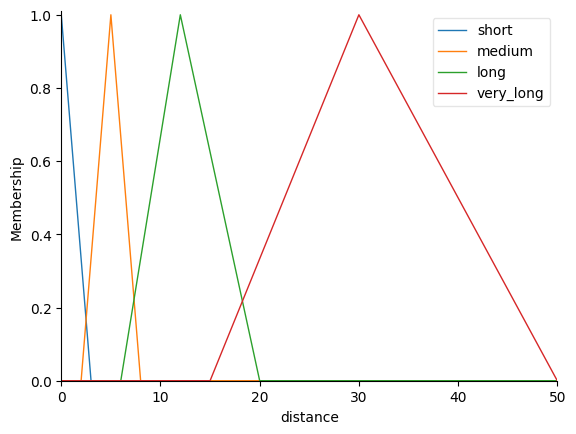

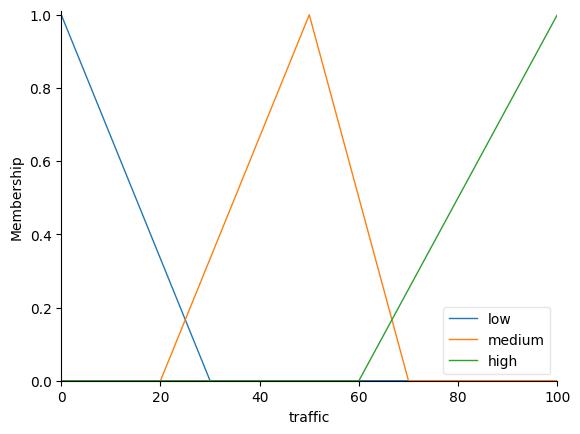

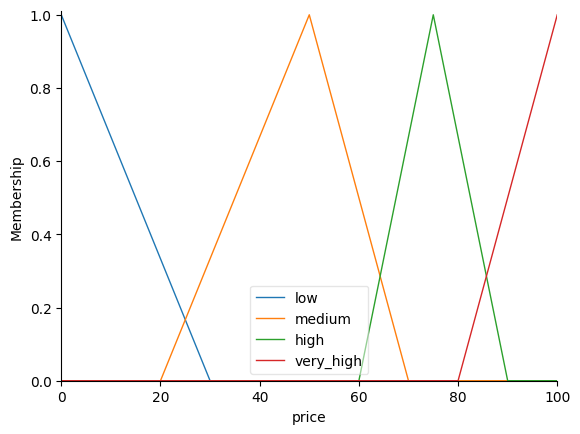

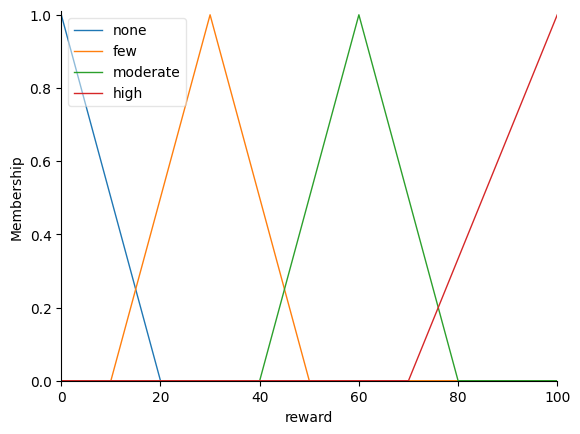

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0,51,1),'distance')
traffic = ctrl.Antecedent(np.arange(0,101,1),'traffic')
demand = ctrl.Antecedent(np.arange(0,101,1),'demand')
weather = ctrl.Antecedent(np.arange(0,101,1),'weather')
rating = ctrl.Antecedent(np.arange(1,5.1,0.1),'rating')
punctuality = ctrl.Antecedent(np.arange(0,101,1),'punctuality')

price = ctrl.Consequent(np.arange(0,101,1),'price')
reward = ctrl.Consequent(np.arange(0,101,1),'reward')

distance['short'] = fuzz.trimf(distance.universe,[0,0,3])
distance['medium'] = fuzz.trimf(distance.universe,[2,5,8])
distance['long'] = fuzz.trimf(distance.universe,[6,12,20])
distance['very_long'] = fuzz.trimf(distance.universe,[15,30,50])
distance.view()

traffic['low'] = fuzz.trimf(traffic.universe,[0,0,30])
traffic['medium'] = fuzz.trimf(traffic.universe,[20,50,70])
traffic['high'] = fuzz.trimf(traffic.universe,[60,100,100])
traffic.view()

demand['low'] = fuzz.trimf(demand.universe,[0,0,30])
demand['medium'] = fuzz.trimf(demand.universe,[20,50,70])
demand['high'] = fuzz.trimf(demand.universe,[60,100,100])

weather['good'] = fuzz.trimf(weather.universe,[0,0,30])
weather['moderate'] = fuzz.trimf(weather.universe,[20,50,70])
weather['bad'] = fuzz.trimf(weather.universe,[60,100,100])

rating['poor'] = fuzz.trimf(rating.universe,[1,1,2.5])
rating['average'] = fuzz.trimf(rating.universe,[2,3,4])
rating['good'] = fuzz.trimf(rating.universe,[3.5,5,5])

punctuality['late'] = fuzz.trimf(punctuality.universe,[0,0,50])
punctuality['ontime'] = fuzz.trimf(punctuality.universe,[40,60,80])
punctuality['early'] = fuzz.trimf(punctuality.universe,[70,100,100])

price['low'] = fuzz.trimf(price.universe,[0,0,30])
price['medium'] = fuzz.trimf(price.universe,[20,50,70])
price['high'] = fuzz.trimf(price.universe,[60,75,90])
price['very_high'] = fuzz.trimf(price.universe,[80,100,100])
price.view()

reward['none'] = fuzz.trimf(reward.universe,[0,0,20])
reward['few'] = fuzz.trimf(reward.universe,[10,30,50])
reward['moderate'] = fuzz.trimf(reward.universe,[40,60,80])
reward['high'] = fuzz.trimf(reward.universe,[70,100,100])
reward.view()

rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high'])
rule6 = ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])
rule9 = ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high'])
rule10 = ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium'])

rule11 = ctrl.Rule(rating['good'] & punctuality['early'], reward['high'])
rule12 = ctrl.Rule(rating['average'] & punctuality['ontime'], reward['moderate'])
rule13 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule14 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['ontime'], reward['high'])
rule15 = ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate'])
rule16 = ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high'])
rule17 = ctrl.Rule(distance['short'] & rating['average'] & punctuality['ontime'], reward['few'])
rule18 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few'])
rule19 = ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])
rule20 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])

price_ctrl = ctrl.ControlSystem([
rule1,rule2,rule3,rule4,rule5,
rule6,rule7,rule8,rule9,rule10
])

reward_ctrl = ctrl.ControlSystem([
rule11,rule12,rule13,rule14,rule15,
rule16,rule17,rule18,rule19,rule20
])

price_sim = ctrl.ControlSystemSimulation(price_ctrl)
reward_sim = ctrl.ControlSystemSimulation(reward_ctrl)

price_sim.input['distance'] = 7
price_sim.input['traffic'] = 80
price_sim.input['demand'] = 75
price_sim.input['weather'] = 60

reward_sim.input['distance'] = 7
reward_sim.input['traffic'] = 80
reward_sim.input['weather'] = 60
reward_sim.input['rating'] = 4.5
reward_sim.input['punctuality'] = 85

price_sim.compute()
reward_sim.compute()

print("Giá chuyến đi:", price_sim.output['price'])
print("Điểm thưởng cho tài xế:", reward_sim.output['reward'])

Mức chiết khấu đề xuất (%): 55.0


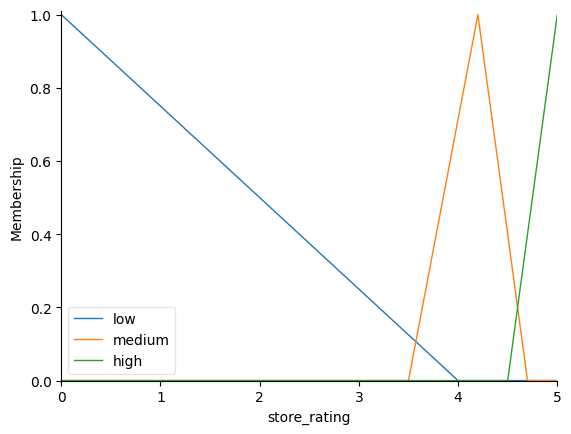

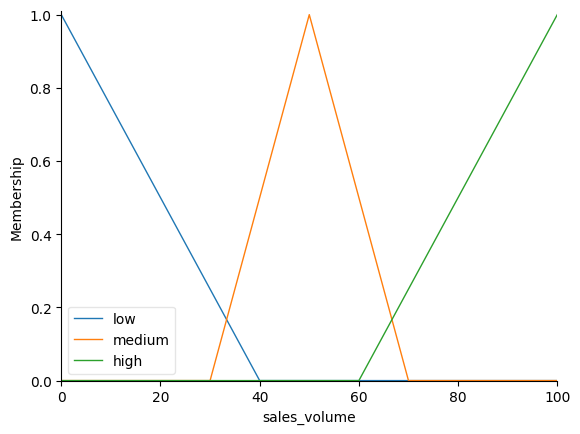

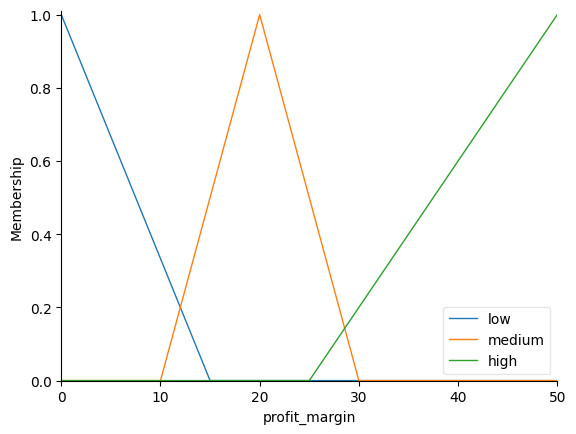

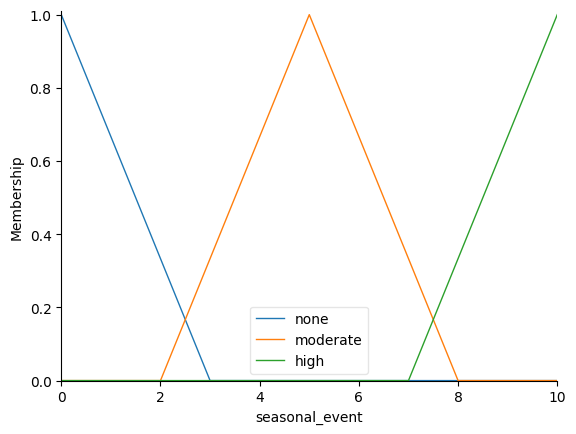

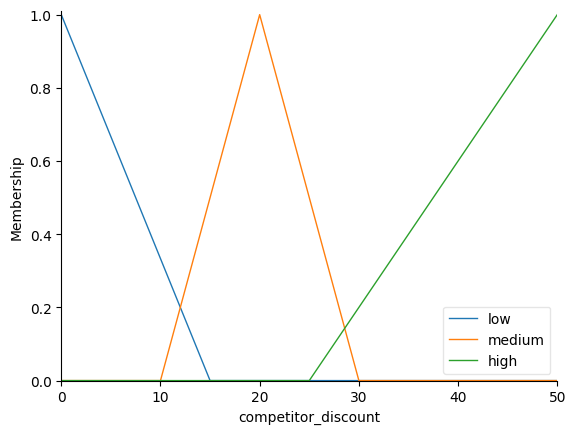

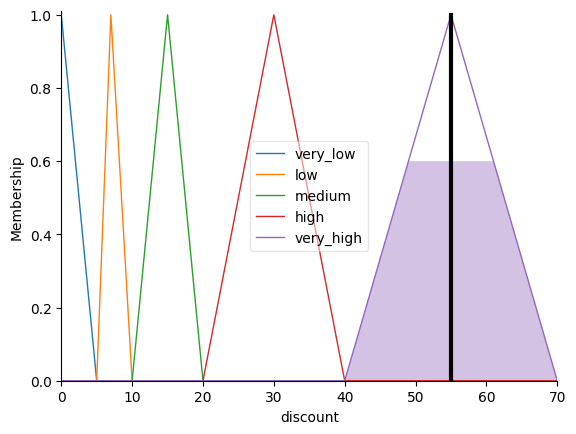

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 51, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_event')
competitor_discount = ctrl.Antecedent(np.arange(0, 51, 1), 'competitor_discount')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

store_rating['low'] = fuzz.trimf(store_rating.universe, [0, 0, 4])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [3.5, 4.2, 4.7])
store_rating['high'] = fuzz.trimf(store_rating.universe, [4.5, 5, 5])
store_rating.view()
sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 0, 40])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [30, 50, 70])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [60, 100, 100])
sales_volume.view()
profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 15])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [10, 20, 30])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [25, 50, 50])
profit_margin.view()
seasonal_event['none'] = fuzz.trimf(seasonal_event.universe, [0, 0, 3])
seasonal_event['moderate'] = fuzz.trimf(seasonal_event.universe, [2, 5, 8])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe, [7, 10, 10])
seasonal_event.view()
competitor_discount['low'] = fuzz.trimf(competitor_discount.universe, [0, 0, 15])
competitor_discount['medium'] = fuzz.trimf(competitor_discount.universe, [10, 20, 30])
competitor_discount['high'] = fuzz.trimf(competitor_discount.universe, [25, 50, 50])
competitor_discount.view()
discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 7, 10])
discount['medium'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['high'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 55, 70])

rule1 = ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'], discount['very_low'])

rule2 = ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'], discount['high'])

rule3 = ctrl.Rule(seasonal_event['high'] & competitor_discount['high'], discount['very_high'])

rule4 = ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount['medium'])

rule5 = ctrl.Rule(competitor_discount['low'] & profit_margin['low'] & sales_volume['high'], discount['very_low'])

rule6 = ctrl.Rule(store_rating['low'] & seasonal_event['none'], discount['medium'])

rule7 = ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount['very_high'])

discount_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7
])

discount_simulation = ctrl.ControlSystemSimulation(discount_ctrl)

discount_simulation.input['store_rating'] = 4.3
discount_simulation.input['sales_volume'] = 50
discount_simulation.input['profit_margin'] = 10
discount_simulation.input['seasonal_event'] = 9
discount_simulation.input['competitor_discount'] = 40

discount_simulation.compute()

print("Mức chiết khấu đề xuất (%):", discount_simulation.output['discount'])

discount.view(sim=discount_simulation)

In [ ]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.9 MB/s eta 0:00:00


Mức chiết khấu đề xuất (%): 40.0


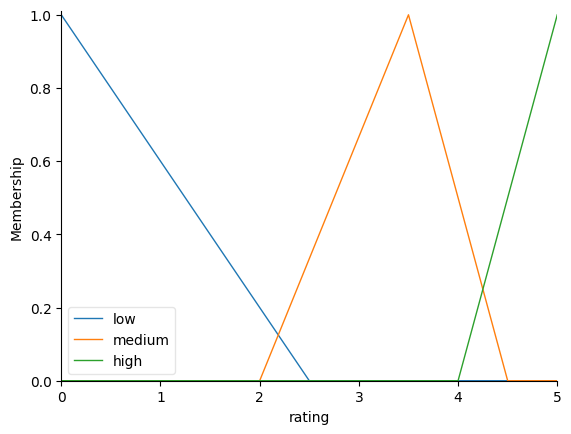

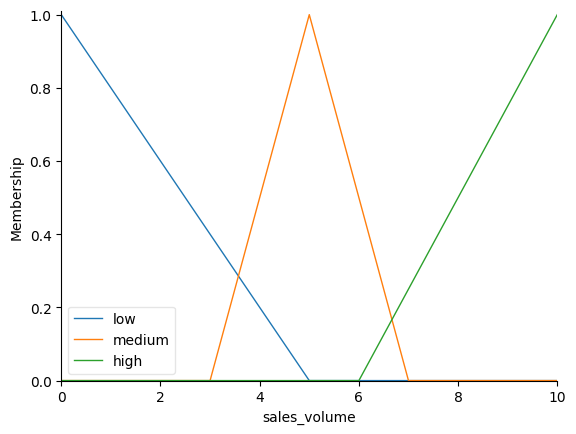

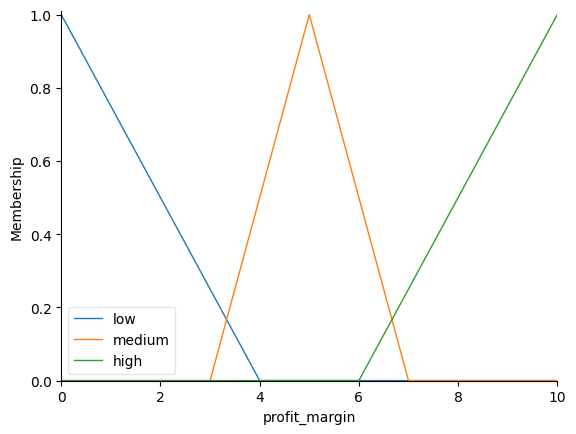

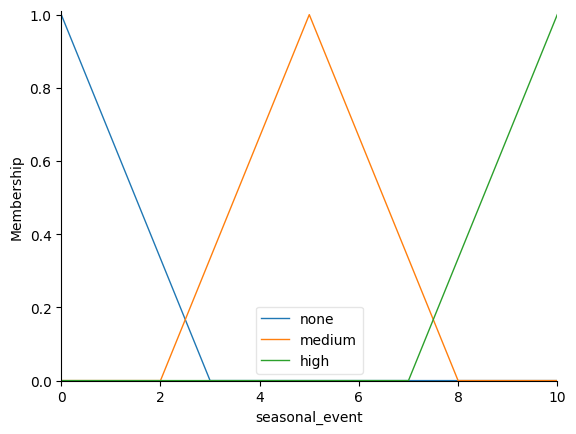

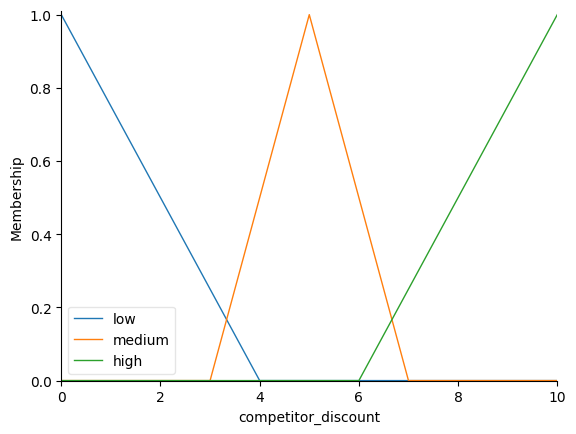

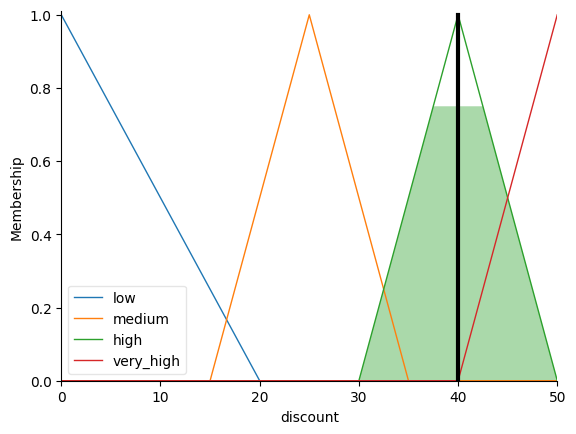

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

rating = ctrl.Antecedent(np.arange(0,5.1,0.1),'rating')
sales_volume = ctrl.Antecedent(np.arange(0,11,1),'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0,11,1),'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0,11,1),'seasonal_event')
competitor_discount = ctrl.Antecedent(np.arange(0,11,1),'competitor_discount')

discount = ctrl.Consequent(np.arange(0,51,1),'discount')

rating['low'] = fuzz.trimf(rating.universe,[0,0,2.5])
rating['medium'] = fuzz.trimf(rating.universe,[2,3.5,4.5])
rating['high'] = fuzz.trimf(rating.universe,[4,5,5])
rating.view()
sales_volume['low'] = fuzz.trimf(sales_volume.universe,[0,0,5])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe,[3,5,7])
sales_volume['high'] = fuzz.trimf(sales_volume.universe,[6,10,10])
sales_volume.view()
profit_margin['low'] = fuzz.trimf(profit_margin.universe,[0,0,4])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe,[3,5,7])
profit_margin['high'] = fuzz.trimf(profit_margin.universe,[6,10,10])
profit_margin.view()
seasonal_event['none'] = fuzz.trimf(seasonal_event.universe,[0,0,3])
seasonal_event['medium'] = fuzz.trimf(seasonal_event.universe,[2,5,8])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe,[7,10,10])
seasonal_event.view()
competitor_discount['low'] = fuzz.trimf(competitor_discount.universe,[0,0,4])
competitor_discount['medium'] = fuzz.trimf(competitor_discount.universe,[3,5,7])
competitor_discount['high'] = fuzz.trimf(competitor_discount.universe,[6,10,10])
competitor_discount.view()
discount['low'] = fuzz.trimf(discount.universe,[0,0,20])
discount['medium'] = fuzz.trimf(discount.universe,[15,25,35])
discount['high'] = fuzz.trimf(discount.universe,[30,40,50])
discount['very_high'] = fuzz.trimf(discount.universe,[40,50,50])

rule1 = ctrl.Rule(rating['low'] & seasonal_event['none'], discount['medium'])
rule2 = ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount['very_high'])
rule3 = ctrl.Rule(seasonal_event['high'] & competitor_discount['high'], discount['high'])
rule4 = ctrl.Rule(rating['medium'] & profit_margin['low'], discount['high'])
rule5 = ctrl.Rule(sales_volume['medium'] & competitor_discount['high'], discount['high'])

discount_ctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['rating'] = 4.3
discount_sim.input['sales_volume'] = 5
discount_sim.input['profit_margin'] = 2
discount_sim.input['seasonal_event'] = 9
discount_sim.input['competitor_discount'] = 9

discount_sim.compute()

print("Mức chiết khấu đề xuất (%):", round(discount_sim.output['discount'],2))

discount.view(sim=discount_sim)

In [ ]:
!pip install scikit-fuzzy

KeyError: 'combine_orders'

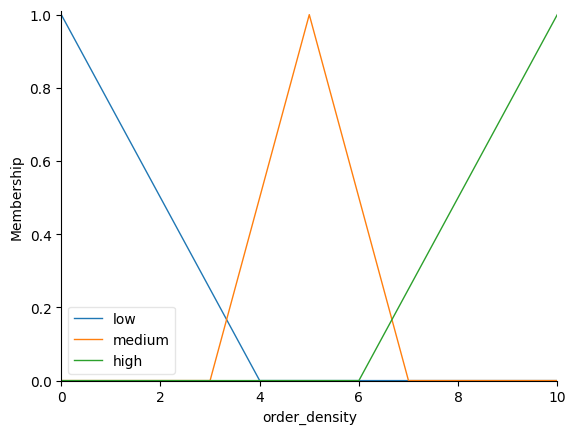

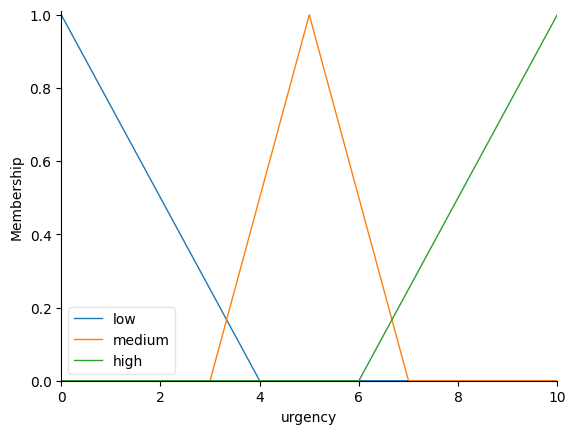

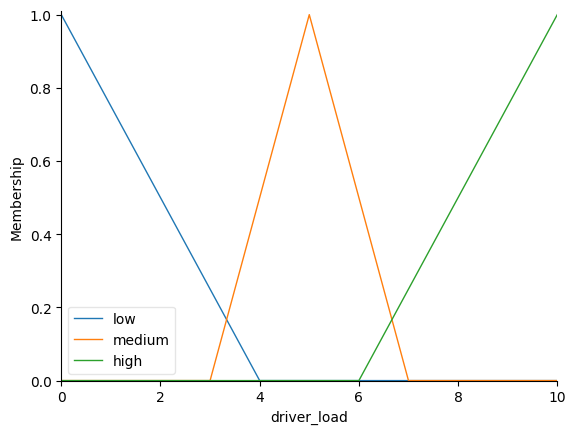

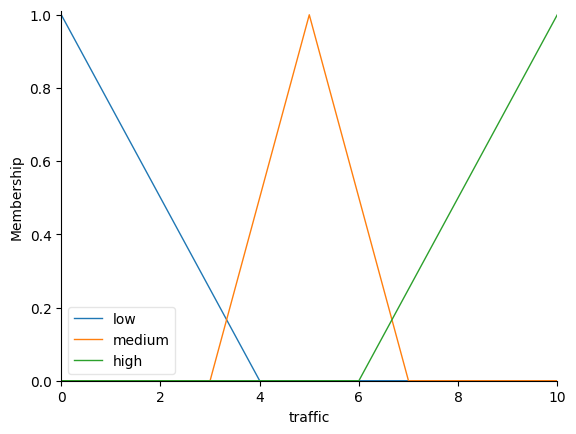

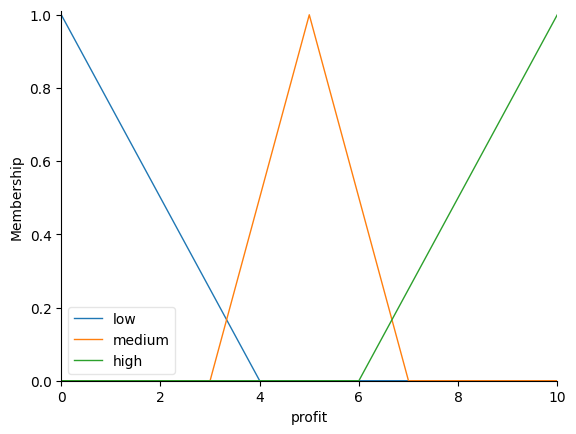

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0,11,1),'order_density')
urgency = ctrl.Antecedent(np.arange(0,11,1),'urgency')
driver_load = ctrl.Antecedent(np.arange(0,11,1),'driver_load')
traffic = ctrl.Antecedent(np.arange(0,11,1),'traffic')
profit = ctrl.Antecedent(np.arange(0,11,1),'profit')

combine_orders = ctrl.Consequent(np.arange(0,11,1),'combine_orders')
priority = ctrl.Consequent(np.arange(0,11,1),'priority')

order_density['low'] = fuzz.trimf(order_density.universe,[0,0,4])
order_density['medium'] = fuzz.trimf(order_density.universe,[3,5,7])
order_density['high'] = fuzz.trimf(order_density.universe,[6,10,10])
order_density.view()
urgency['low'] = fuzz.trimf(urgency.universe,[0,0,4])
urgency['medium'] = fuzz.trimf(urgency.universe,[3,5,7])
urgency['high'] = fuzz.trimf(urgency.universe,[6,10,10])
urgency.view()
driver_load['low'] = fuzz.trimf(driver_load.universe,[0,0,4])
driver_load['medium'] = fuzz.trimf(driver_load.universe,[3,5,7])
driver_load['high'] = fuzz.trimf(driver_load.universe,[6,10,10])
driver_load.view()
traffic['low'] = fuzz.trimf(traffic.universe,[0,0,4])
traffic['medium'] = fuzz.trimf(traffic.universe,[3,5,7])
traffic['high'] = fuzz.trimf(traffic.universe,[6,10,10])
traffic.view()
profit['low'] = fuzz.trimf(profit.universe,[0,0,4])
profit['medium'] = fuzz.trimf(profit.universe,[3,5,7])
profit['high'] = fuzz.trimf(profit.universe,[6,10,10])
profit.view()
combine_orders['few'] = fuzz.trimf(combine_orders.universe,[0,0,4])
combine_orders['some'] = fuzz.trimf(combine_orders.universe,[3,5,7])
combine_orders['many'] = fuzz.trimf(combine_orders.universe,[6,10,10])

priority['low'] = fuzz.trimf(priority.universe,[0,0,4])
priority['medium'] = fuzz.trimf(priority.universe,[3,5,7])
priority['high'] = fuzz.trimf(priority.universe,[6,10,10])

rule1 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic['low'], combine_orders['many'])
rule2 = ctrl.Rule(order_density['medium'] & traffic['high'] & urgency['medium'], combine_orders['some'])
rule3 = ctrl.Rule(driver_load['high'] & order_density['high'] & profit['medium'], combine_orders['some'])
rule4 = ctrl.Rule(order_density['low'] & urgency['high'] & traffic['medium'], combine_orders['some'])
rule5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine_orders['some'])

rule6 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])
rule7 = ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium'])
rule8 = ctrl.Rule(urgency['low'] & order_density['high'] & profit['low'], priority['low'])
rule9 = ctrl.Rule(order_density['medium'], combine_orders['some'])#đảm bảo output luôn được kích hoạt

system = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9])
sim = ctrl.ControlSystemSimulation(system)

sim.input['order_density'] = 9
sim.input['urgency'] = 5
sim.input['driver_load'] = 2
sim.input['traffic'] = 5
sim.input['profit'] = 5

sim.compute()

print("Số đơn nên gộp:", round(sim.output['combine_orders'],2))
print("Mức ưu tiên giao:", round(sim.output['priority'],2))

combine_orders.view(sim=sim)
priority.view(sim=sim)

Số đơn nên gộp: 0
Mức ưu tiên giao: 5.0


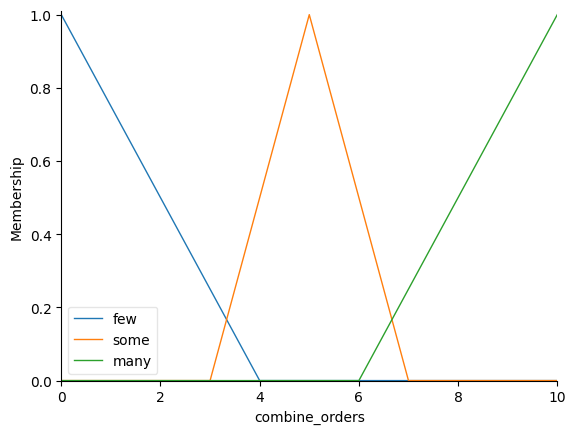

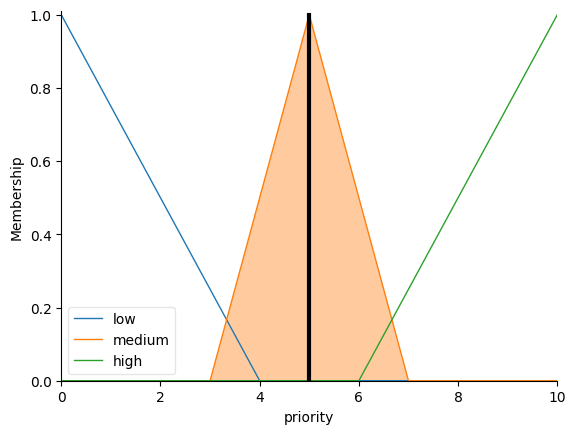

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0,11,1),'order_density')
urgency = ctrl.Antecedent(np.arange(0,11,1),'urgency')
driver_load = ctrl.Antecedent(np.arange(0,11,1),'driver_load')
traffic = ctrl.Antecedent(np.arange(0,11,1),'traffic')
profit = ctrl.Antecedent(np.arange(0,11,1),'profit')

combine_orders = ctrl.Consequent(np.arange(0,11,1),'combine_orders')
priority = ctrl.Consequent(np.arange(0,11,1),'priority')

order_density['low'] = fuzz.trimf(order_density.universe,[0,0,4])
order_density['medium'] = fuzz.trimf(order_density.universe,[3,5,7])
order_density['high'] = fuzz.trimf(order_density.universe,[6,10,10])

urgency['low'] = fuzz.trimf(urgency.universe,[0,0,4])
urgency['medium'] = fuzz.trimf(urgency.universe,[3,5,7])
urgency['high'] = fuzz.trimf(urgency.universe,[6,10,10])

driver_load['low'] = fuzz.trimf(driver_load.universe,[0,0,4])
driver_load['medium'] = fuzz.trimf(driver_load.universe,[3,5,7])
driver_load['high'] = fuzz.trimf(driver_load.universe,[6,10,10])

traffic['low'] = fuzz.trimf(traffic.universe,[0,0,4])
traffic['medium'] = fuzz.trimf(traffic.universe,[3,5,7])
traffic['high'] = fuzz.trimf(traffic.universe,[6,10,10])

profit['low'] = fuzz.trimf(profit.universe,[0,0,4])
profit['medium'] = fuzz.trimf(profit.universe,[3,5,7])
profit['high'] = fuzz.trimf(profit.universe,[6,10,10])

combine_orders['few'] = fuzz.trimf(combine_orders.universe,[0,0,4])
combine_orders['some'] = fuzz.trimf(combine_orders.universe,[3,5,7])
combine_orders['many'] = fuzz.trimf(combine_orders.universe,[6,10,10])

priority['low'] = fuzz.trimf(priority.universe,[0,0,4])
priority['medium'] = fuzz.trimf(priority.universe,[3,5,7])
priority['high'] = fuzz.trimf(priority.universe,[6,10,10])

rule1 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic['low'], combine_orders['many'])
rule2 = ctrl.Rule(order_density['medium'] & traffic['high'] & urgency['medium'], combine_orders['some'])
rule3 = ctrl.Rule(driver_load['high'] & order_density['high'] & profit['medium'], combine_orders['some'])
rule4 = ctrl.Rule(order_density['low'] & urgency['high'] & traffic['medium'], combine_orders['some'])
rule5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine_orders['some'])

rule6 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])
rule7 = ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium'])
rule8 = ctrl.Rule(urgency['low'] & order_density['high'] & profit['low'], priority['low'])

rule9 = ctrl.Rule(order_density['medium'], combine_orders['some'])
rule10 = ctrl.Rule(urgency['medium'], priority['medium'])

system = ctrl.ControlSystem([
    rule1,rule2,rule3,rule4,rule5,
    rule6,rule7,rule8,
    rule9,rule10
])

sim = ctrl.ControlSystemSimulation(system)

sim.input['order_density'] = 9
sim.input['urgency'] = 5
sim.input['driver_load'] = 2
sim.input['traffic'] = 5
sim.input['profit'] = 5

sim.compute()

print("Số đơn nên gộp:", round(sim.output.get('combine_orders',0),2))
print("Mức ưu tiên giao:", round(sim.output.get('priority',0),2))

combine_orders.view(sim=sim)
priority.view(sim=sim)